In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.optim as optim
import pickle
import torch.nn as nn
from nice.algorithms.connectivity_AT import *
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import gc as gc
import warnings
warnings.filterwarnings("ignore")


In [3]:
file_numbers = [1,2, 4, 8, 14, 15, 20, 23]

structure = {f'dataset_{file_number}': {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
} for file_number in file_numbers}

def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  # Gaussian filter along the time axis

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z

def get_data(file_number):
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    data = pickle.load(open(file_path, 'rb'))

    label_left = data['label_left'][0]
    label_right = data['label_right'][0]  #for class of input
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]


    num_trials, num_samples, num_neurons = left.shape

    # for j in range(0, num_trials):
    #     for i in range(0, num_neurons):
    #         count_left = np.count_nonzero(left[j, :, i] == 1)
    #         if count_left > 0:
    #             left[j, :, i] /= count_left
    #         count_right = np.count_nonzero(right[j, :, i] == 1)
    #         if count_right > 0:
    #             right[j, :, i] /= count_right



    left = preprocess(left)
    right = preprocess(right)
       
       
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    # Splitting left and right
    #try without smoothing too
    # left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
    # right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
    left_attleft = left[left_indices]
    right_attleft = right[left_indices]
    att_attleft = att[left_indices]

    # left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
    # right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
    left_attright = left[right_indices]
    right_attright = right[right_indices]
    att_attright = att[right_indices]

    return left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright
##e.g. dataset 1 gives left_attleft of shape (469 trials, 500 time points, 160 spikes)


def collect_data(file_numbers):
    l_al, l_ar, r_al, r_ar, a_al, a_ar = [], [], [], [], [], []
    for file_number in file_numbers:
        left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright = get_data(file_number)
        l_al.append(left_attleft)
        l_ar.append(left_attright)
        r_al.append(right_attleft)
        r_ar.append(right_attright)
        a_al.append(att_attleft)
        a_ar.append(att_attright)
       
    return l_al, l_ar, r_al, r_ar, a_al, a_ar

   

In [4]:
def smooth_data(data, sigma=1):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  #Gaussian filter along the time axis

def normalize_inputs(x_train, x_test, x_val):   #note that this will take the mean and stc based on the training data only
 
    if np.isnan(x_train).any():
        raise ValueError("Data contains NaN values after normalization.")

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(x_val, dtype=torch.float32)
    )

def normalize_targets(y_train, y_test, y_val):
    #standard scaler
    mean = np.mean(y_train, axis=0, keepdims=True)
    std = np.std(y_train, axis=0, keepdims=True)
    std[std == 0] = 1  # avoid division by zero
    y_train = (y_train - mean) / std
    y_test = (y_test - mean) / std
    y_val = (y_val - mean) / std
    

    print('shape of target', y_train.shape)
    return (
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )


In [5]:
def prep_data(x_list, y_list, batch_size=16, shuffle=True):
    #concatenating all of the datasets
    x_raw = np.concatenate(x_list, axis=0)   # (N, T, neurons)
    y_raw = np.concatenate(y_list, axis=0)   # (N, T, 1) or (N, T)
    print('shape of inputs:',  x_raw.shape)
    print('shape of outputs:', y_raw.shape)

    #finding the output counts
    y_counts = np.sum(y_raw, axis=1) 
    print('number of firings:', y_counts.shape)

    #ttv split
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        x_raw, y_counts, test_size=0.2, random_state=42, shuffle=shuffle
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=42, shuffle=shuffle
    )

    #then norm based on training data
    X_tr, X_te, X_val = normalize_inputs(X_tr, X_te, X_val)
    y_tr, y_te, y_val = normalize_targets(y_tr, y_te, y_val)

    #wrap as tensors
    def make_ds(X, y):
        #x might already be a torch.Tensor (from normalize_inputs)
        # if isinstance(X, np.ndarray):
        #     X = torch.from_numpy(X).float()
        # else:
        #     X = X.float()
        # if isinstance(y, np.ndarray):
        #     y = torch.from_numpy(y).float()
        # else:
        #     y = y.float()
            
        return TensorDataset(X, y)

    train_ds = make_ds(X_tr, y_tr)
    val_ds   = make_ds(X_val, y_val)
    test_ds  = make_ds(X_te,  y_te)

    #build dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, drop_last=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

    return train_loader, val_loader, test_loader


In [6]:
import torch.nn.functional as F

class TemporalAttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # project each hidden state to a scalar score
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, h):  
        # h: (B, T, D)
        # 1) compute un‑normalized scores for each t
        alpha = self.score(h).squeeze(-1)       # → (B, T)
        # 2) normalize into attention weights
        alpha = F.softmax(alpha, dim=1)             # → (B, T)
        # 3) weighted sum of hidden states
        c = torch.einsum('bt, btd -> bd', alpha, h)  
        return c                             # → (B, D)

class SpikingAttentionLSTM(nn.Module):
    def __init__(
        self,
        input_dim = 160, 
        hidden_dim = 128,
        output_dim = 80, 
        num_layers = 2, 
        dropout = 0.3,
        pool: str = 'last',
    ):
        super().__init__()
        self.pool = pool
        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim, 
            batch_first = True,
            num_layers = num_layers,
            dropout = dropout if num_layers > 1 else 0.0,  #dropout only applies if num_layers > 1

        )
        if self.pool == 'att':
            self.attention = TemporalAttentionPool(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)  #dropout layer

    def forward(self, x):
        out_seq, (h_n, _) = self.lstm(x)
        if self.pool == 'mean':
            # mean over *all* time‑steps
            feat = out_seq.mean(dim=1)         # (batch, hidden_dim)
        elif self.pool == 'att':
            # attention pooling over time
            feat = self.attention(out_seq)
        else:
            # default: last hidden state of the top LSTM layer
            feat = h_n[-1]                     # (batch, hidden_dim)
        
        feat = self.dropout(feat)
        return self.fc(feat)                  # (batch, output_dim)

class SimpleAvgMLP(nn.Module):
    def __init__(self, input_dim, output_dim=250, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        
        # Create a list to hold all layers
        layers = []
        
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.LeakyReLU())
        layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.LeakyReLU())
            layers.append(nn.Dropout(dropout))
        
        # Create sequential model for hidden layers
        self.hidden_layers = nn.Sequential(*layers)
        
        # Output layer
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)
        
    def forward(self, x):
        # x: [batch, time, neurons]
        # collapse time by mean:
        pooled = x.mean(dim=1)         # [batch, neurons]
        h = self.hidden_layers(pooled)  # Apply all hidden layers
        out = self.output_layer(h)      # [batch, output_dim]
        return out  # Return None for attention weights to match LSTM interface

class BidirectionalLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=250, num_layers=2, dropout=0.3):
        super(BidirectionalLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for bidirectional
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Output layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: [batch, time, features]
        
        # LSTM forward pass
        lstm_out, _ = self.lstm(x)  # lstm_out: [batch, time, hidden*2]
        
        # Attention mechanism
        attn_weights = F.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        
        # Apply dropout and final linear layer
        context = self.dropout(context)
        output = self.fc(context)
        
        return output#, attn_weights

class VanillaLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=250, num_layers=2, dropout=0.3):
        super(VanillaLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch, time, neurons]
        _, (h_n, _) = self.lstm(x)
        # Use the last hidden state from the top LSTM layer
        feat = h_n[-1]  # (batch, hidden_dim)
        feat = self.dropout(feat)
        return self.fc(feat)  # (batch, output_dim)
    

In [ ]:
def train(model, train_loader, val_loader,
           criterion, epochs=1000, clip_value = 1.0, 
           lr = 1e-3, wd = 1e-5, patience = 20):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, verbose=True
    )
    loss_history = []
    validation_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None
    epochs_since_improvement = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)  #gradient clipping
            optimizer.step()
            epoch_loss += loss.item()

        loss_history.append(epoch_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
           for xb_val, yb_val in val_loader:
                val_loss += criterion(model(xb_val), yb_val).item()
        val_loss_item = val_loss / len(val_loader)
        validation_loss_history.append(val_loss_item)

        scheduler.step(val_loss_item)  # Reduce learning rate if validation loss doesn't improve

        #early stopping
        if val_loss_item < best_val_loss:
            best_val_loss = val_loss_item
            best_model_state = model.state_dict()
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if epochs_since_improvement >= patience:
            print(f"Early stopping at epoch {epoch} with validation loss: {best_val_loss:.4f}")
            break

        if epoch % 1 == 0:
            clear_output(wait=True)  #clears the Jupyter output cell
            plt.figure(figsize=(10, 7))
            plt.plot(loss_history, label = 'Training Loss')
            plt.plot(validation_loss_history, label = 'Validation Loss')
            plt.legend()
            plt.xlim(0, epochs)
            plt.ylim(0.0, 1.0)
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Losses')
            plt.grid(True)
            plt.show()


    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return loss_history, validation_loss_history


In [8]:
def create_model(model, n_neurons_in, output_dim, hidden_dims, dropout):
    if model == 'LSTM':
        return SpikingAttentionLSTM(
            input_dim=n_neurons_in,
            hidden_dim=hidden_dims[0],
            output_dim=output_dim,
            num_layers=2, 
            dropout=dropout)
    
    elif model == 'MLP':
        return SimpleAvgMLP(
            input_dim=n_neurons_in,
            output_dim=output_dim,
            hidden_dims=hidden_dims,
            dropout=dropout)
    
    elif model == 'BiLSTM':
        return BidirectionalLSTM(
            input_dim=n_neurons_in, 
            hidden_dim=hidden_dims[0], 
            output_dim=output_dim, 
            num_layers=2, 
            dropout=dropout)
    
    elif model == 'VanillaLSTM':
        return VanillaLSTM(
            input_dim=n_neurons_in,
            hidden_dim=hidden_dims[0],
            output_dim=output_dim,
            num_layers=3,
            dropout=dropout)
    else:
        raise ValueError("Unknown model type")

In [34]:
def run_model(model_type = 'MLP', output_dim = 80, 
              data_in = None, data_pred = None, batch_size = 32, criterion = nn.MSELoss(),
               epochs = 150, lr = 1e-2, wd = 1e-4, patience = 10, hidden_dims = [256, 128, 96], 
               dropout = 0.3):

    # ─── Prepare the data ─────────────────────────────────────────────────────
    train_loader, val_loader, test_loader = prep_data(
        data_in, data_pred,
        batch_size=batch_size,
        shuffle=True
    )

    # ─── Inspect input dim ────────────────────────────────────────────────────
    sample_x, _ = next(iter(train_loader))
    n_neurons_in = sample_x.shape[2]
    print('n_neurons:', n_neurons_in)

    # ─── Instantiate your model ───────────────────────────────────────────────
    model = create_model(model_type, n_neurons_in, output_dim, hidden_dims, dropout)


    # ─── Train ────────────────────────────────────────────────────────────────
    criterion = criterion
    loss_history, validation_loss_history = train(
        model,
        train_loader,
        val_loader,  
        criterion,
        epochs=epochs,
        lr=lr,
        wd=wd,
        patience=patience
    )

    # ─── Final evaluation on test set ────────────────────────────────────────
    model.eval()
    test_mse = 0.0
    all_preds, all_trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            test_mse += criterion(preds, yb).item()
            all_preds.append(preds.cpu().numpy())
            all_trues.append(yb.cpu().numpy())

    test_mse /= len(test_loader)
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test R2: {r2_score(np.concatenate(all_trues), np.concatenate(all_preds)):.4f}")
    print(f"RMSE", np.sqrt(test_mse))


    # ─── (Optional) flatten predictions & truths into arrays ─────────────────
    preds = np.concatenate(all_preds, axis=0)  # shape (n_test, 1)
    truths   = np.concatenate(all_trues, axis=0)  # same shape
    print('y_pred shape:', preds.shape)
    print('y_true shape:', truths.shape)

    return preds, truths, test_mse, loss_history, validation_loss_history, model


In [10]:
l_al, _, r_al, _, a_al, _ = collect_data(file_numbers)

print('shape of left_attleft',l_al[0].shape)  #this is just the shape for the first file
print('shape of right_attleft',r_al[0].shape)
print('shape of attention layer left',a_al[0].shape)


shape of left_attleft (328, 250, 160)
shape of right_attleft (328, 250, 160)
shape of attention layer left (328, 250, 80)


In [ ]:
#hidden_dims = [[256, 128, 96], [320, 128, 96], [256, 320, 128], [96, 128, 320], [128, 256, 128], [128, 128, 128, 128], [128, 128, 128], [96, 96, 96], [320, 320, 320]]
#MSE values for different hidden dimensions: [0.17369034306870568, 0.1687820860081249, 0.15997378610902363, 0.15709378570318222, 0.1630522815717591, 0.1724230936831898, 0.16161868472894034, 0.16607914782232708, 0.15280378775464165]

# hidden_dims = [[320, 320, 320], [420, 420, 420], [96, 128, 320, 428], [320, 320, 320, 320], [128, 128, 128, 128], [160, 320, 320, 420, 420]]
# MSE values for different hidden dimensions: [0.14396179384655422, 0.14183145927058327, 0.16042174481683308, 0.15852672772275078, 0.17008783668279648, 0.1632925851477517]

# hidden_dims = [[420, 420, 420], [480, 480, 480], [520, 520, 520], [640, 640, 640]]
# MSE values for different hidden dimensions: [0.1421605803900295, 0.141816516717275, 0.14023396207226646, 0.14126071830590567]

# hidden_dims = [[1024, 1024, 1024], [640, 520, 480], [520, 480, 420], [800, 800, 800]]
# MSE values for different hidden dimensions: [0.13878527200884289, 0.14228356215688917, 0.1446195501420233, 0.13829193347030216]

# hidden_dims = [[2048, 2048, 2048], [600, 600, 600], [1000, 1000, 1000], [700, 800, 900]]
# MSE values for different hidden dimensions: [0.13851067423820496, 0.13805724349286821, 0.13899278392394385, 0.1382176462146971]

# hidden_dims = [[2048, 2048, 2048, 2048],[4092, 4092],[4092, 2048, 1028],[900, 800, 600]]
# MSE values for different hidden dimensions: [0.13616175535652372, 0.14181982891427147, 0.14029992206229103, 0.1379802707168791]

# hidden_dims = [[800, 700, 600],[700, 600, 500],[600, 500, 400],[700, 700, 700]]
# MSE values for different hidden dimensions: [0.13873176525036493, 0.1396168371041616, 0.14379768735832638, 0.13643168326881197

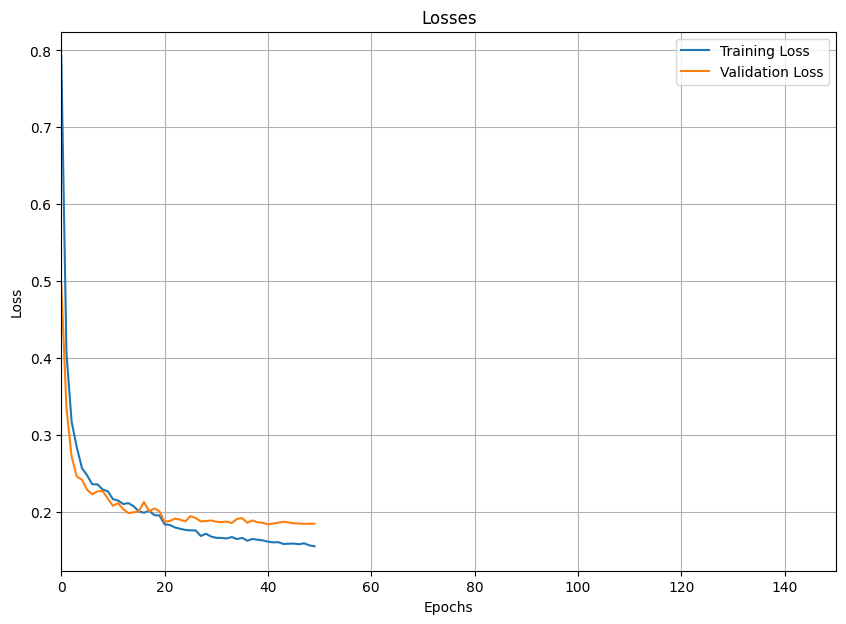

Early stopping at epoch 50 with validation loss: 0.1835
Test MSE: 0.1407
Test R2: 0.8075
RMSE 0.37504037003974106
y_pred shape: (262, 80)
y_true shape: (262, 80)
average MSE for left attention left: 0.04432242716298962
average RMSE for left attention left: 0.1183878872914192
average R2 for left attention left: 0.25574918050893514
average MSE for left attention left: 0.04432242716298962
average RMSE for left attention left: 0.1183878872914192
average R2 for left attention left: 0.25574918050893514


In [ ]:
mse_l_al = []
rmse_l_al = []
r2_l_al = []

for i in range(0, 10):   
    preds_l_al, truths_l_al, test_mse_l_al, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = l_al, data_pred = a_al,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10,
        dropout=0.3
    )

    mse_l_al.append(test_mse_l_al)
    rmse_l_al.append(np.sqrt(test_mse_l_al))
    r2_l_al.append(r2_score(truths_l_al, preds_l_al))

    del preds_l_al, truths_l_al, test_mse_l_al
    gc.collect()



In [32]:
avg_mse_l_al = np.mean(mse_l_al) 
avg_remse_l_al = np.mean(rmse_l_al) 
avg_r2_l_al = np.mean(r2_l_al) 
std_mse_l_al = np.std(mse_l_al, ddof = 1)
std_remse_l_al = np.std(rmse_l_al, ddof = 1)
std_r2_l_al = np.std(r2_l_al, ddof = 1)

print('average MSE for left attention left:', avg_mse_l_al, '±', std_mse_l_al)
print('average RMSE for left attention left:', avg_remse_l_al, '±', std_remse_l_al)
print('average R2 for left attention left:', avg_r2_l_al, '±', std_r2_l_al)


average MSE for left attention left: 0.14015982126196225 ± 0.0013464215943180906
average RMSE for left attention left: 0.37437537121618697 ± 0.0017958868760550115
average R2 for left attention left: 0.808749920129776 ± 0.0019230427797358185


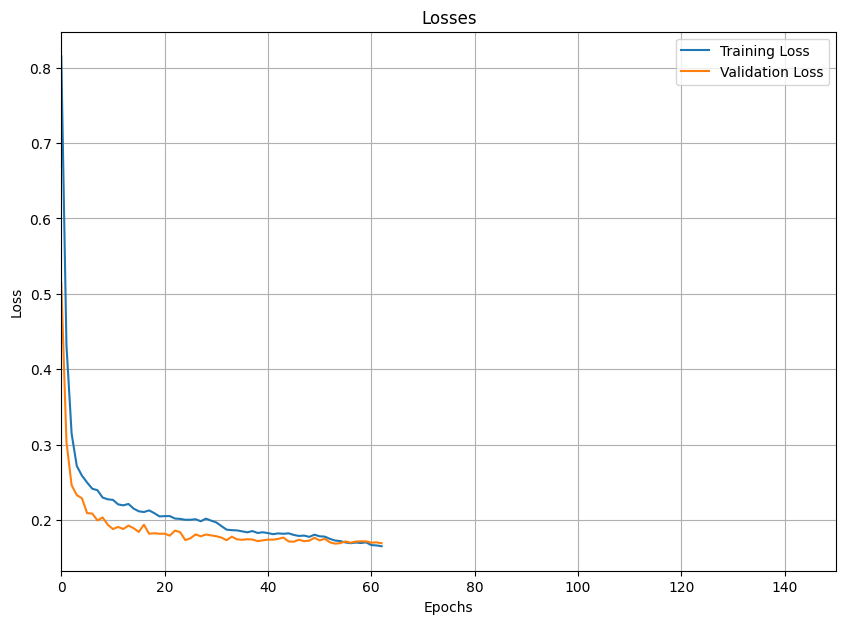

Early stopping at epoch 63 with validation loss: 0.1687
Test MSE: 0.1661
Test R2: 0.7722
RMSE 0.40752283424013763
y_pred shape: (262, 80)
y_true shape: (262, 80)
average MSE for right attention left: 0.16554722835620245 ± 0.0005304303761616815
average RMSE for right attention left: 0.40687448404539583 ± 0.000651996076486217
average R2 for right attention left: 0.7735425174236298 ± 0.0017867297463257446
average MSE for right attention left: 0.16554722835620245 ± 0.0005304303761616815
average RMSE for right attention left: 0.40687448404539583 ± 0.000651996076486217
average R2 for right attention left: 0.7735425174236298 ± 0.0017867297463257446


In [35]:
mse_r_al = []
rmse_r_al = []
r2_r_al = []

for i in range(0, 10):
    preds_r_al, truths_r_al, test_mse_r_al, _, _, _= run_model(    
        model_type= 'MLP', output_dim = 80,
        data_in = r_al, data_pred = a_al,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_r_al.append(test_mse_r_al)
    rmse_r_al.append(np.sqrt(test_mse_r_al))
    r2_r_al.append(r2_score(truths_r_al, preds_r_al))

    del preds_r_al, truths_r_al, test_mse_r_al
    gc.collect()

    print('finished iteration ', i)

avg_mse_r_al = np.mean(mse_r_al) 
avg_remse_r_al = np.mean(rmse_r_al)
avg_r2_r_al = np.mean(r2_r_al)
std_mse_r_al = np.std(mse_r_al, ddof = 1)
std_remse_r_al = np.std(rmse_r_al, ddof = 1)
std_r2_r_al = np.std(r2_r_al, ddof = 1)


print('average MSE for right attention left:', avg_mse_r_al, '±', std_mse_r_al)
print('average RMSE for right attention left:', avg_remse_r_al, '±', std_remse_r_al)
print('average R2 for right attention left:', avg_r2_r_al, '±', std_r2_r_al)

In [13]:
_, l_ar, _, r_ar, _, a_ar = collect_data(file_numbers)

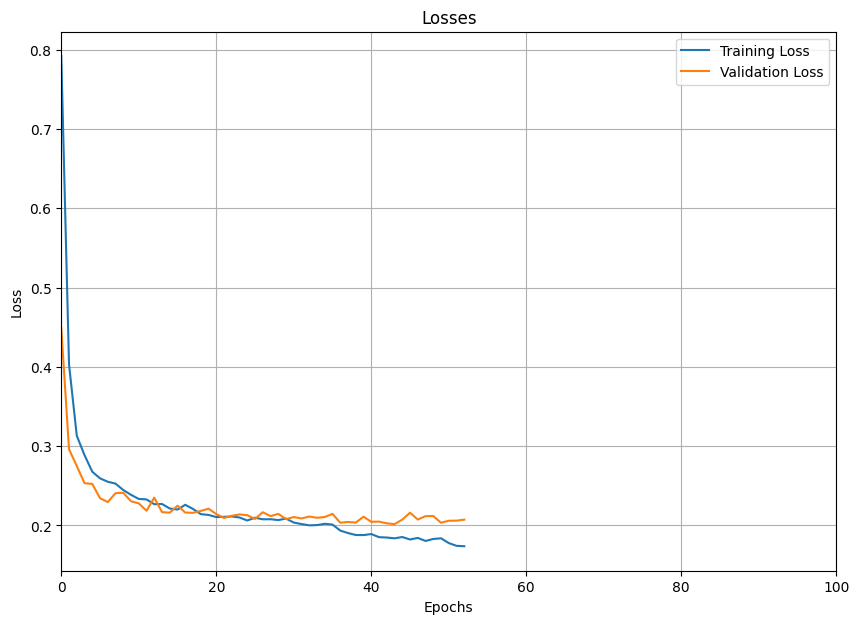

Early stopping at epoch 53 with validation loss: 0.2016
Test MSE: 0.2038
y_pred shape: (269, 80)
y_true shape: (269, 80)


In [ ]:
mse_l_ar = []
rmse_l_ar = []
r2_l_ar = []

for i in range(0, 10):
    preds_l_ar, truths_l_ar, test_mse_l_ar, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = l_ar, data_pred = a_ar,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=100,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_l_ar.append(test_mse_l_ar)
    rmse_l_ar.append(np.sqrt(test_mse_l_ar))
    r2_l_ar.append(r2_score(truths_l_ar, preds_l_ar))

    del preds_l_ar, truths_l_ar, test_mse_l_ar
    gc.collect()

    print('finished iteration ', i)


avg_mse_l_ar = np.mean(mse_l_ar) 
avg_remse_l_ar = np.mean(rmse_l_ar) 
avg_r2_l_ar = np.mean(r2_l_ar) 
std_mse_l_ar = np.std(mse_l_ar, ddof = 1)
std_remse_l_ar = np.std(rmse_l_ar, ddof = 1)
std_r2_l_ar = np.std(r2_l_ar, ddof = 1)

print('average MSE for left attention right:', avg_mse_l_ar, '±', std_mse_l_ar)
print('average RMSE for left attention right:', avg_remse_l_ar, '±', std_remse_l_ar)
print('average R2 for left attention right:', avg_r2_l_ar, '±', std_r2_l_ar)



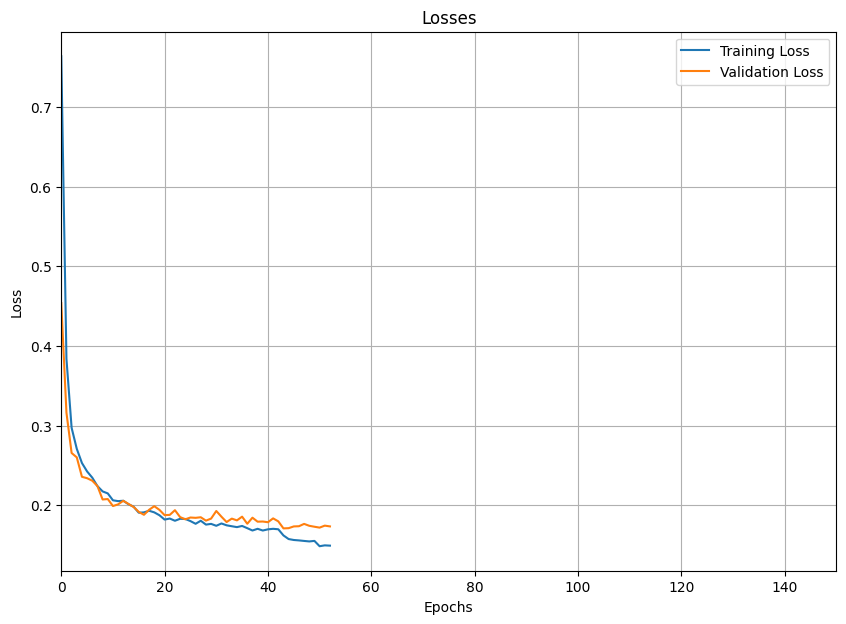

Early stopping at epoch 53 with validation loss: 0.1710
Test MSE: 0.1741
y_pred shape: (269, 80)
y_true shape: (269, 80)


In [ ]:
mse_r_ar = []
rmse_r_ar = []
r2_r_ar = []

for i in range(0, 10):
    preds_r_ar, truths_r_ar, test_mse_r_ar, _, _, _ = run_model(
        model_type= 'MLP', output_dim = 80,
        data_in = r_ar, data_pred = a_ar,
        batch_size=32, criterion = nn.MSELoss(),
        epochs=150,
        lr=1e-3,
        wd=1e-4,
        hidden_dims = [900, 800, 600],
        patience=10
    )

    mse_r_ar.append(test_mse_r_ar)
    rmse_r_ar.append(np.sqrt(test_mse_r_ar))
    r2_r_ar.append(r2_score(truths_r_ar, preds_r_ar))

    del preds_r_ar, truths_r_ar, test_mse_r_ar
    gc.collect()

    print('finished iteration ', i)

avg_mse_r_ar = np.mean(mse_r_ar) 
avg_remse_r_ar = np.mean(rmse_r_ar) 
avg_r2_r_ar = np.mean(r2_r_ar) 
std_mse_r_ar = np.std(mse_r_ar, ddof = 1)
std_remse_r_ar = np.std(rmse_r_ar, ddof = 1)
std_r2_r_ar = np.std(r2_r_ar, ddof = 1)

print('average MSE for right attention right:', avg_mse_r_ar, '±', std_mse_r_ar)
print('average RMSE for right attention right:', avg_remse_r_ar, '±', std_remse_r_ar)
print('average R2 for right attention right:', avg_r2_r_ar, '±', std_r2_r_ar)

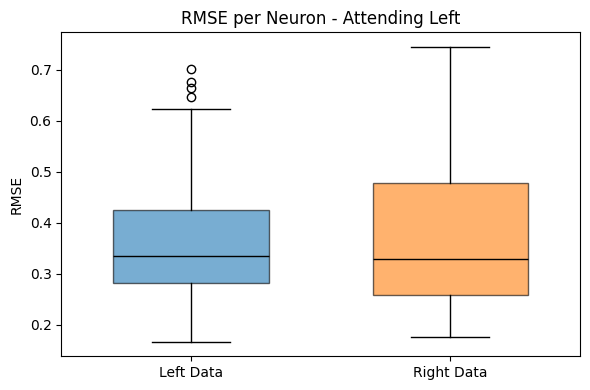

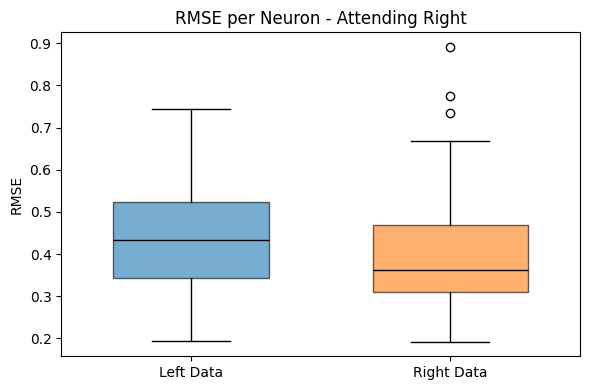

In [21]:
# plt.figure(figsize=(12, 4))
# plt.plot(np.mean(truths_l_al, axis=0), marker='x', color='black', linestyle='-', label='True')
# plt.plot(np.mean(preds_l_al, axis=0), marker='x', color='red', linestyle='-', label='Predicted - IN')
# plt.plot(np.mean(preds_r_al, axis=0), marker='x', color='blue', linestyle='-', label='Predicted - OUT')
# plt.legend()
# plt.title('Prediction vs Truth - Left Attending')
# plt.xlabel('Neuron')
# plt.ylabel('Mean Value')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12, 4))
# plt.plot(np.mean(truths_r_al, axis=0), marker='x', color='black', linestyle='-', label='True')
# plt.plot(np.mean(preds_l_ar, axis=0), marker='x', color='blue', linestyle='-', label='Predicted - OUT')
# plt.plot(np.mean(preds_r_ar, axis=0), marker='x', color='red', linestyle='-', label='Predicted - IN')
# plt.legend()
# plt.title('Prediction vs Truth - Right Attending')
# plt.xlabel('Neuron')
# plt.ylabel('Mean Value')
# plt.tight_layout()
# plt.show()

def plot_in_vs_out(in_vals, out_vals,
                   labels=('In','Out'),
                   ylabel='Pearson r',
                   title=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    # tell boxplot to draw filled boxes (patch_artist=True)
    bp = ax.boxplot([in_vals, out_vals],
                    widths=0.6,
                    notch=False,
                    patch_artist=True)
    
    # color sequence: C0 is blue, C1 is orange in the default Matplotlib cycle
    colors = ['C0','C1']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # (optional) make whiskers/caps match box edge
    for element in ['whiskers','caps']:
        for line in bp[element]:
            line.set(color='k')
            
    
    for median in bp['medians']:
        median.set(color='k', linewidth=1)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

def per_neuron_rmse(y_true, y_pred):
    # y_true, y_pred are (n_neurons, n_points)
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

rmse_l_al  = per_neuron_rmse(truths_l_al,  preds_l_al)
rmse_r_al = per_neuron_rmse(truths_r_al, preds_r_al)

plot_in_vs_out(rmse_l_al, rmse_r_al, 
                labels=('Left Data', 'Right Data'),
                ylabel='RMSE',
                title='RMSE per Neuron - Attending Left')  

rmse_l_ar = per_neuron_rmse(truths_l_ar, preds_l_ar)
rmse_r_ar = per_neuron_rmse(truths_r_ar, preds_r_ar)

plot_in_vs_out(rmse_l_ar, rmse_r_ar,
                labels=('Left Data', 'Right Data'),
                ylabel='RMSE',
                title='RMSE per Neuron - Attending Right')


In [22]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np

diffs_left = rmse_l_al- rmse_r_al
t_stat_left, p_t_left = ttest_rel(rmse_l_al, rmse_r_al)
w_stat_left, p_w_left = wilcoxon(rmse_l_al, rmse_r_al)

diffs_right = rmse_l_ar - rmse_r_ar
t_stat_right, p_t_right = ttest_rel(rmse_l_ar, rmse_r_ar)
w_stat_right, p_w_right = wilcoxon(rmse_l_ar, rmse_r_ar)

mean_diff_left = np.mean(diffs_left)
sd_diff_left   = np.std(diffs_left, ddof=1)
cohens_d_left  = mean_diff_left / sd_diff_left

mean_diff_right = np.mean(diffs_right)
sd_diff_right   = np.std(diffs_right, ddof=1)
cohens_d_right  = mean_diff_right / sd_diff_right

print(f"Paired t‑test:     t = {t_stat_left:.2f}, p = {p_t_left:.3f}")
print(f"Wilcoxon test:     W = {w_stat_left:.2f}, p = {p_w_left:.3f}")
print(f"Mean(left–right) = {mean_diff_left:.3f}, Cohen’s d = {cohens_d_left:.2f}")

print(f"Paired t‑test:     t = {t_stat_right:.2f}, p = {p_t_right:.3f}")
print(f"Wilcoxon test:     W = {w_stat_right:.2f}, p = {p_w_right:.3f}")
print(f"Mean(left–right) = {mean_diff_right:.3f}, Cohen’s d = {cohens_d_right:.2f}")



Paired t‑test:     t = -1.58, p = 0.117
Wilcoxon test:     W = 1432.00, p = 0.367
Mean(left–right) = -0.019, Cohen’s d = -0.18
Paired t‑test:     t = 2.81, p = 0.006
Wilcoxon test:     W = 1030.00, p = 0.005
Mean(left–right) = 0.038, Cohen’s d = 0.31


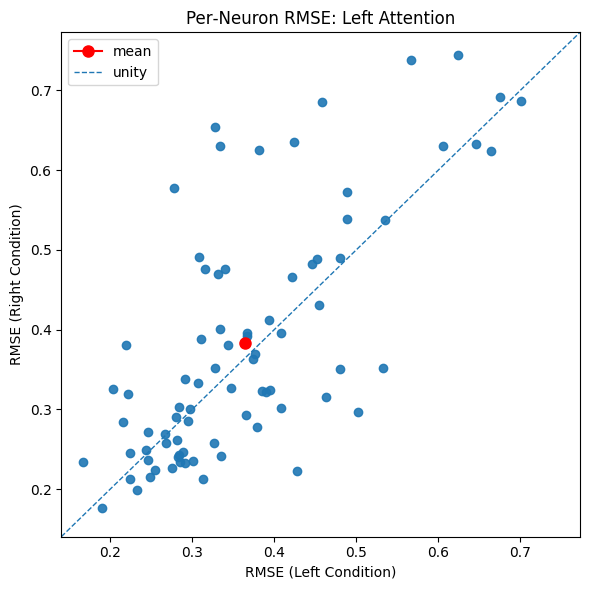

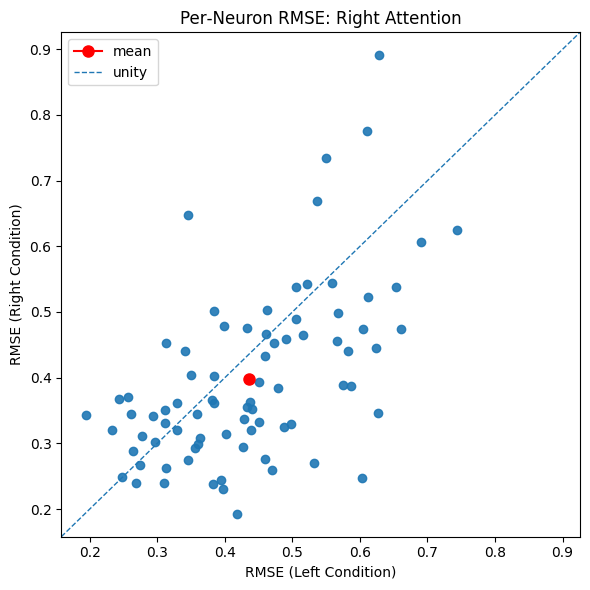

In [25]:
fig, ax = plt.subplots(figsize=(6,6))

# scatter of Left vs Right
ax.scatter(rmse_l_al, rmse_r_al, alpha=0.9)
ax.plot(np.mean(rmse_l_al), np.mean(rmse_r_al), marker='o', color='red', markersize=8, label='mean')

# unity line: from the min to max of both axes
lims = [
    np.min([ax.get_xlim()[0], ax.get_ylim()[0]]),
    np.max([ax.get_xlim()[1], ax.get_ylim()[1]])
]
ax.plot(lims, lims, linestyle='--', linewidth=1, label='unity')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('RMSE (Left Condition)')
ax.set_ylabel('RMSE (Right Condition)')
ax.set_title('Per‑Neuron RMSE: Left Attention')
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6,6))

# scatter of Left vs Right
ax.scatter(rmse_l_ar, rmse_r_ar, alpha=0.9)
ax.plot(np.mean(rmse_l_ar), np.mean(rmse_r_ar), marker='o', color='red', markersize=8, label='mean')

# unity line: from the min to max of both axes
lims = [
    np.min([ax.get_xlim()[0], ax.get_ylim()[0]]),
    np.max([ax.get_xlim()[1], ax.get_ylim()[1]])
]
ax.plot(lims, lims, linestyle='--', linewidth=1, label='unity')

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('RMSE (Left Condition)')
ax.set_ylabel('RMSE (Right Condition)')
ax.set_title('Per‑Neuron RMSE: Right Attention')
ax.legend()
plt.tight_layout()
plt.show()

